# Heart Disease Diagnosis: Building and Training the ANN

Same structure as the diabetes and malaria training notebooks. All the
data work is already done, this notebook only focuses on the network:

1. Load the prepared data (from CSV, real patient records)
2. Build the ANN
3. Train it
4. Visualize training
5. Evaluate on the test set (ROC curve, confusion matrix)
6. Save the trained model
7. Make a clean, simple prediction on a new patient

Run `01_heart_disease_data_preparation.ipynb` first if you haven't already.


## Step 1: Import libraries

In [2]:
import json
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras

from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve)

tf.random.set_seed(42)
np.random.seed(42)


## Step 2: Load the prepared data

In [3]:
train_df = pd.read_csv('heart_train.csv')
val_df = pd.read_csv('heart_val.csv')
test_df = pd.read_csv('heart_test.csv')

with open('heart_metadata.json') as f:
    metadata = json.load(f)

feature_cols = metadata['feature_cols']
scaler_mean = np.array(metadata['scaler_mean'], dtype=np.float32)
scaler_scale = np.array(metadata['scaler_scale'], dtype=np.float32)

X_train = train_df[feature_cols].values.astype(np.float32)
y_train = train_df['target'].values.astype(np.float32)
X_val = val_df[feature_cols].values.astype(np.float32)
y_val = val_df['target'].values.astype(np.float32)
X_test = test_df[feature_cols].values.astype(np.float32)
y_test = test_df['target'].values.astype(np.float32)

print(f"Train: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}")
print(f"Number of features: {X_train.shape[1]}")


Train: (211, 18)
Val:   (46, 18)
Test:  (46, 18)
Number of features: 18


## Step 3: Build the ANN

With only ~211 training rows (far fewer than the diabetes dataset's
~537), a big network would overfit almost immediately. We use a smaller
version of the same architecture family, still Dense + BatchNormalization
+ ReLU + Dropout, but with fewer neurons per layer, matched to how little
data we actually have.

In [4]:
def build_ann(n_features):
    inputs = keras.Input(shape=(n_features,), name='features')

    x = keras.layers.Dense(64, kernel_regularizer=keras.regularizers.l2(1e-4))(inputs)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation('relu')(x)
    x = keras.layers.Dropout(0.3)(x)

    x = keras.layers.Dense(32, kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation('relu')(x)
    x = keras.layers.Dropout(0.3)(x)

    x = keras.layers.Dense(16)(x)
    x = keras.layers.Activation('relu')(x)
    x = keras.layers.Dropout(0.2)(x)

    outputs = keras.layers.Dense(1, activation='sigmoid', name='prob')(x)

    return keras.Model(inputs, outputs, name='HeartDiseaseANN')


model = build_ann(X_train.shape[1])
model.summary()


Model: "HeartDiseaseANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ features (InputLayer)                │ (None, 18)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           1,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ prob (Dense)                         │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,225 (16.50 KB)

 Trainable params: 4,033 (15.75 KB)

 Non-trainable params: 192 (768.00 B)

## Step 4: Compile the model

In [5]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
    ]
)


## Step 5: Train the model

Same three callbacks as before. With such a small dataset, keeping
`restore_best_weights=True` matters even more, it's very easy for a small
network to overfit a small dataset within a few dozen epochs.

In [6]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_auc', patience=25,
        restore_best_weights=True, mode='max', verbose=1),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc', factor=0.5, patience=10,
        min_lr=1e-6, mode='max', verbose=1),
    keras.callbacks.ModelCheckpoint(
        'best_heart.keras', monitor='val_auc',
        save_best_only=True, mode='max', verbose=0),
]

history = model.fit(
    X_train, y_train,
    epochs=300, batch_size=16,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1,
)

print(f"\nEpochs run:   {len(history.history['loss'])}")
print(f"Best val AUC: {max(history.history['val_auc']):.4f}")


Epoch 1/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - accuracy: 0.5640 - auc: 0.5842 - loss: 0.7125 - precision: 0.5680 - recall: 0.8348 - val_accuracy: 0.6304 - val_auc: 0.4905 - val_loss: 0.7015 - val_precision: 0.5952 - val_recall: 1.0000 - learning_rate: 5.0000e-04
Epoch 2/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5640 - auc: 0.5932 - loss: 0.6971 - precision: 0.5714 - recall: 0.8000 - val_accuracy: 0.6087 - val_auc: 0.5933 - val_loss: 0.6833 - val_precision: 0.5897 - val_recall: 0.9200 - learning_rate: 5.0000e-04
Epoch 3/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5735 - auc: 0.6378 - loss: 0.6713 - precision: 0.5786 - recall: 0.8000 - val_accuracy: 0.6522 - val_auc: 0.6505 - val_loss: 0.6675 - val_precision: 0.6216 - val_recall: 0.9200 - learning_rate: 5.0000e-04
Epoch 4/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6161 - auc: 0.6671 - loss: 0.6542 - precision: 0.6232 - recall: 0.7478 - val_accuracy: 0.6739 - val_auc: 0.7038 - val_loss: 

## Step 6: Visualize training

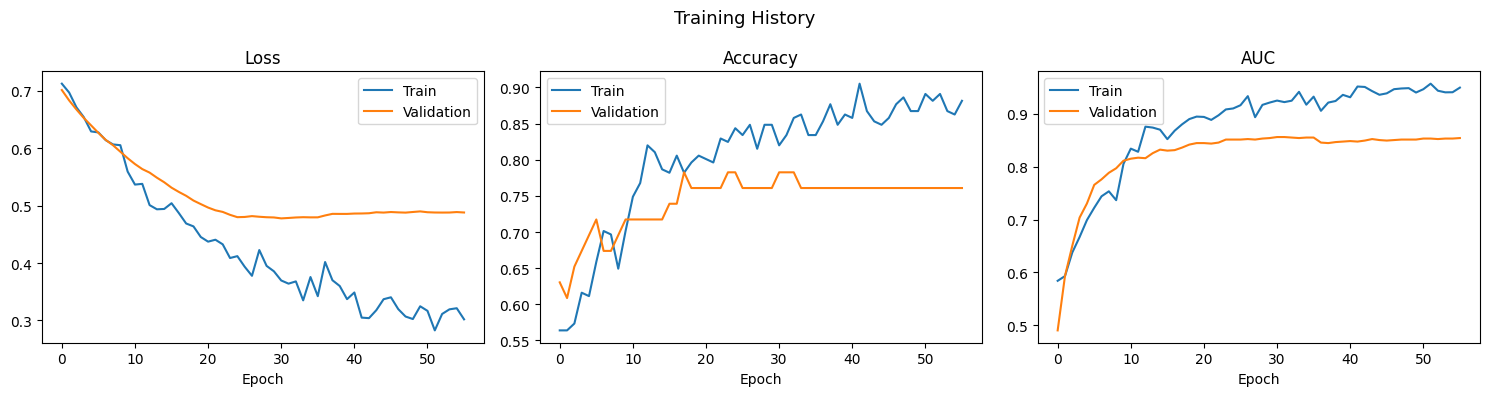

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Validation')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(history.history['auc'], label='Train')
axes[2].plot(history.history['val_auc'], label='Validation')
axes[2].set_title('AUC')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.suptitle('Training History', fontsize=13)
plt.tight_layout()
plt.savefig('heart_training_history.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 7: Evaluate on the test set

A reminder for students: the test set here is only around 45 real
patients. That's normal for real medical datasets, they're expensive and
slow to collect, unlike the 800-row synthetic examples we've used before.
Expect these metrics to jump around more between runs than they did on
larger datasets, that variability is itself a real, useful lesson about
working with small clinical datasets.

In [8]:
model.load_weights('best_heart.keras')

test_results = model.evaluate(X_test, y_test, verbose=0)
for name, value in zip(model.metrics_names, test_results):
    print(f"{name:<12}: {value:.4f}")


loss        : 0.4600
compile_metrics: 0.7826


### ROC curve

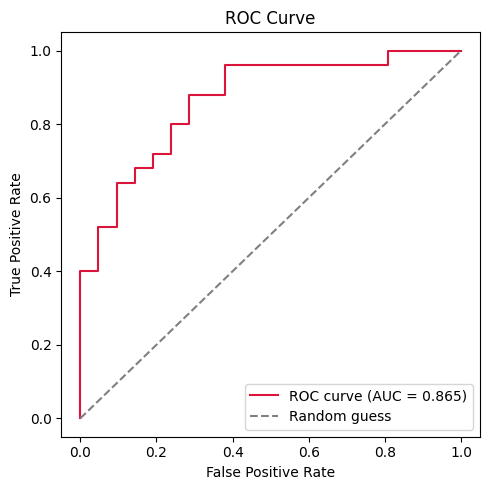

ROC-AUC: 0.8648


In [9]:
y_prob = model.predict(X_test, verbose=0).flatten()
auc_score = roc_auc_score(y_test, y_prob)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, color='crimson', label=f'ROC curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.savefig('heart_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"ROC-AUC: {auc_score:.4f}")


### Classification report and confusion matrix

              precision    recall  f1-score   support

  No Disease       0.82      0.67      0.74        21
     Disease       0.76      0.88      0.81        25

    accuracy                           0.78        46
   macro avg       0.79      0.77      0.78        46
weighted avg       0.79      0.78      0.78        46



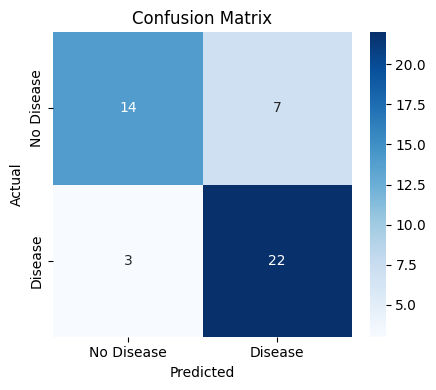

In [10]:
y_pred = (y_prob >= 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('heart_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 8: Save the trained model

In [12]:
model.save('heart_ann.keras')

with open('heart_inference_kit.pkl', 'wb') as f:
    pickle.dump({
        'feature_cols': feature_cols,
        'scaler_mean': scaler_mean,
        'scaler_scale': scaler_scale,
    }, f)

print("Saved heart_ann.keras")
print("Saved heart_inference_kit.pkl")


Saved heart_ann.keras
Saved heart_inference_kit.pkl


## Step 9: Make a prediction on a new patient

In [13]:
def predict_patient(patient, model, feature_cols, scaler_mean, scaler_scale):
    patient = patient.copy()

    # Add the same engineered features from data preparation
    patient['Max_HR_Ratio'] = patient['thalach'] / (220 - patient['age'])
    patient['High_Cholesterol'] = float(patient['chol'] >= 240)
    patient['High_BP'] = float(patient['trestbps'] >= 140)
    patient['Significant_ST_Depression'] = float(patient['oldpeak'] >= 2)
    patient['Age_x_Chol'] = patient['age'] * patient['chol']

    # Put the features in the exact same order the model expects
    row = np.array([patient[col] for col in feature_cols], dtype=np.float32)

    # Scale by hand, same formula the training data went through
    row_scaled = ((row - scaler_mean) / scaler_scale).reshape(1, -1)

    probability = model.predict(row_scaled, verbose=0)[0][0]
    prediction = 'Heart Disease' if probability >= 0.5 else 'No Heart Disease'

    print(f"Probability of heart disease: {probability:.1%}")
    print(f"Prediction: {prediction}")


In [14]:
# Two real patients, pulled straight from the test set columns (hand-typed
# here for a clear demo, values match the original heart.csv format)
patient_1 = {
    'age': 63, 'sex': 1, 'cp': 3, 'trestbps': 145, 'chol': 233, 'fbs': 1,
    'restecg': 0, 'thalach': 150, 'exang': 0, 'oldpeak': 2.3, 'slope': 0,
    'ca': 0, 'thal': 1,
}
print("Patient 1")
predict_patient(patient_1, model, feature_cols, scaler_mean, scaler_scale)

print()

patient_2 = {
    'age': 41, 'sex': 0, 'cp': 1, 'trestbps': 130, 'chol': 204, 'fbs': 0,
    'restecg': 0, 'thalach': 172, 'exang': 0, 'oldpeak': 1.4, 'slope': 2,
    'ca': 0, 'thal': 2,
}
print("Patient 2")
predict_patient(patient_2, model, feature_cols, scaler_mean, scaler_scale)


Patient 1
Probability of heart disease: 53.6%
Prediction: Heart Disease

Patient 2
Probability of heart disease: 94.6%
Prediction: Heart Disease


### Done

This notebook used real patient records end to end, real symptoms, real
measurements, a real diagnosis outcome. The pipeline is identical to the
diabetes project: clean, engineer clinically-informed features, train a
small ANN, and evaluate honestly with ROC/AUC rather than accuracy alone.
The one genuinely new lesson here is what a small real dataset does to
your results: noisier metrics, a smaller network to avoid overfitting,
and more caution before trusting any single number.